In [ ]:
# Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Load data
url = "https://raw.githubusercontent.com/uras-alkaya/AI-Projects/refs/heads/main/teknasyon-case-ai-datascientist-3/datasets/churn_train.csv"
df = pd.read_csv(url)

In [ ]:
# Search for negative values in numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    if (df[col] < 0).sum() > 0:
        print(f"There are {(df[col] < 0).sum()} negative values in the {col} column.")

There are 7 negative values in the user_spendings column.
There are 49 negative values in the reloads_sum column.
There are 2 negative values in the sms_outgoing_spendings column.
There are 2 negative values in the sms_outgoing_to_offnet_spendings column.
There are 10 negative values in the sms_incoming_spendings column.
There are 48 negative values in the gprs_spendings column.
There are 32 negative values in the last_100_reloads_sum column.


In [ ]:
# Delete negative values
columns_with_negatives = [
    "user_spendings",
    "reloads_sum",
    "sms_outgoing_spendings",
    "sms_outgoing_to_offnet_spendings",
    "sms_incoming_spendings",
    "gprs_spendings",
    "last_100_reloads_sum"
]

# Filter rows with non-negative values
df_cleaned = df[(df[columns_with_negatives] >= 0).all(axis=1)]

print(f"{df.shape[0] - df_cleaned.shape[0]} rows deleted. Remaining rows: {df_cleaned.shape[0]}")

# Update the original df
df = df_cleaned

116 rows deleted. Remaining rows: 59884


In [ ]:
# Check for negative values again
for col in columns_with_negatives:
    if (df[col] < 0).any():
        print(f"{col}: Still contains negatives!")
    else:
        print(f"{col}: All negatives removed ✅")

user_spendings: All negatives removed ✅
reloads_sum: All negatives removed ✅
sms_outgoing_spendings: All negatives removed ✅
sms_outgoing_to_offnet_spendings: All negatives removed ✅
sms_incoming_spendings: All negatives removed ✅
gprs_spendings: All negatives removed ✅
last_100_reloads_sum: All negatives removed ✅


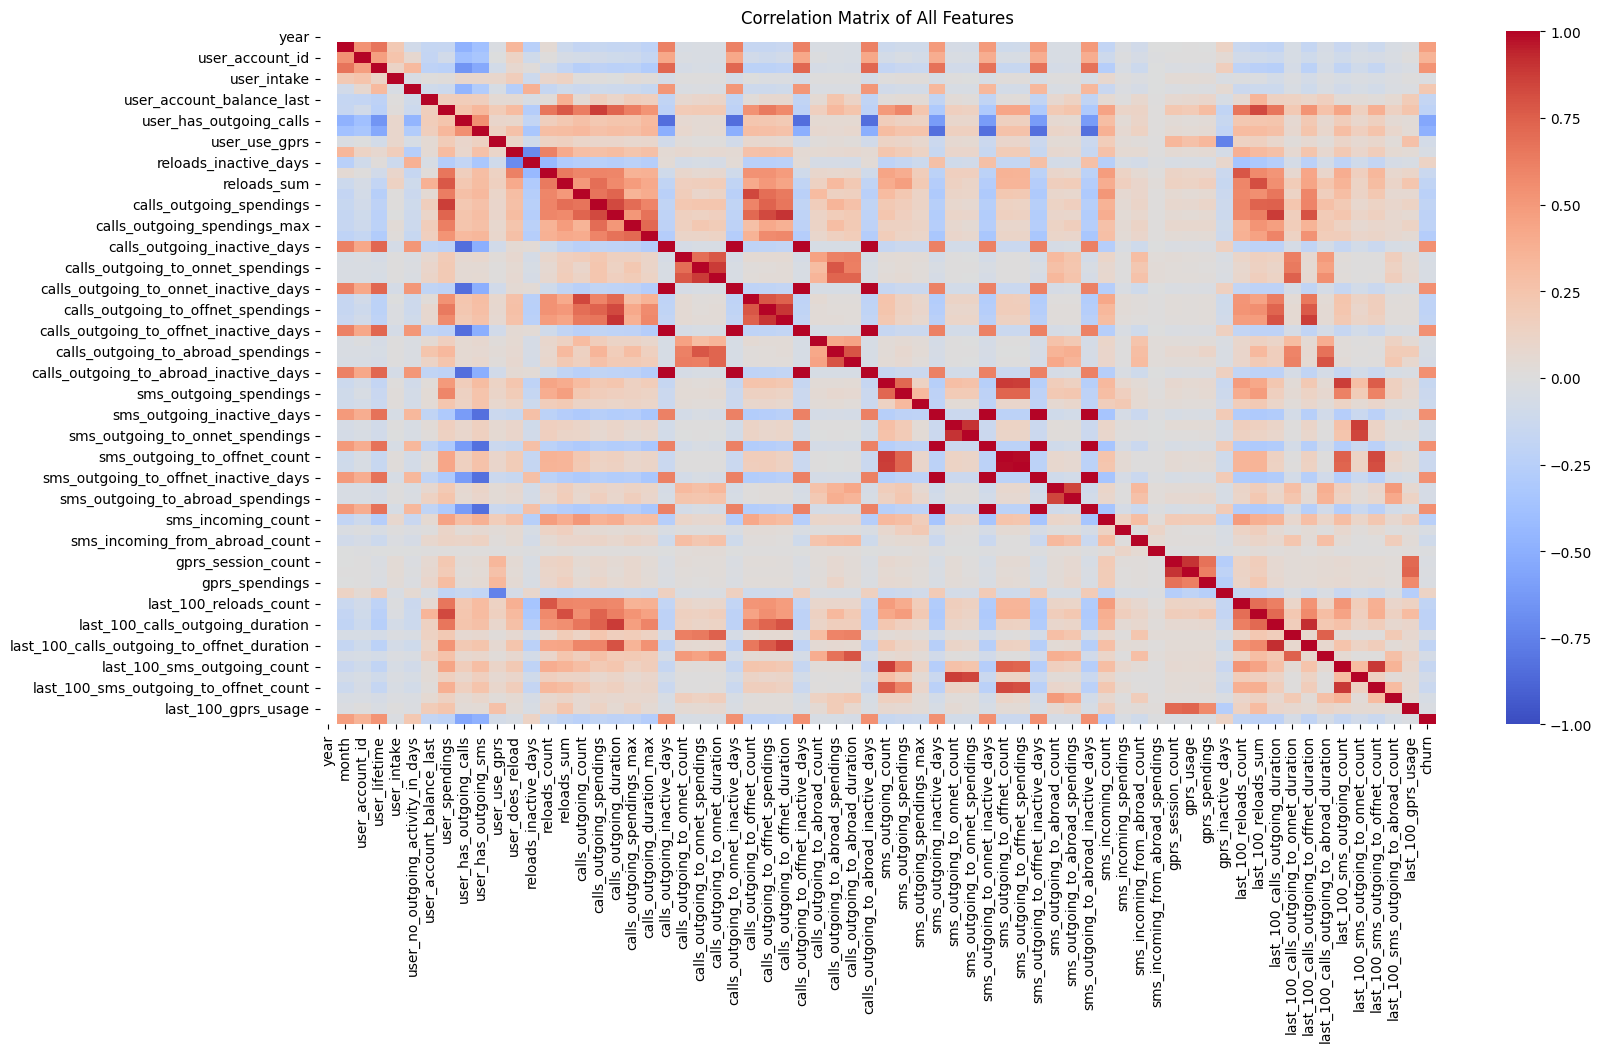

In [ ]:
# Correlation Matrix
plt.figure(figsize=(18,9))
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of All Features")
plt.show()

In [ ]:
# Meaningless Columns
df = df.drop(columns=["user_account_id",])

In [ ]:
# Find columns with constant or very low variance
low_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", low_variance_cols)

# Remove if necessary
df = df.drop(columns=low_variance_cols)

Constant columns: ['year']


In [ ]:
import numpy as np

# 1. Outgoing call ratio
df["outgoing_call_ratio"] = df["calls_outgoing_count"] / (df["user_lifetime"] + 1)

# 2. Average daily spending
df["avg_spending_per_day"] = df["user_spendings"] / (df["user_lifetime"] + 1)

# 3. Average spending per outgoing call duration
df["spending_per_call_out_duration"] = df["user_spendings"] / (df["calls_outgoing_duration"] + 1)

# 4. Ratio of inactive days to total calls
df["inactive_days_ratio"] = (
    df["calls_outgoing_to_offnet_inactive_days"] +
    df["calls_outgoing_to_onnet_inactive_days"] +
    df["calls_outgoing_to_abroad_inactive_days"]
) / (df["user_lifetime"] + 1)

# 5. Total call duration per active day
df["call_duration_per_day"] = df["calls_outgoing_duration"] / (df["user_lifetime"] + 1)

# 6. SMS inactive days ratio
df["sms_inactive_ratio"] = (
    df["sms_outgoing_to_onnet_inactive_days"] + df["sms_outgoing_to_offnet_inactive_days"]
) / (df["user_lifetime"] + 1)

# 7. Average spending per last 100 call duration
df["spending_per_last100_call_duration"] = df["user_spendings"] / (df["last_100_calls_outgoing_duration"] + 1)

# 8. International call inactivity ratio
df["abroad_call_inactivity_ratio"] = df["calls_outgoing_to_abroad_inactive_days"] / (df["user_lifetime"] + 1)

# 9. Spending/lifetime efficiency
df["spending_lifetime_efficiency"] = df["user_spendings"] / (df["user_lifetime"] + 1)

# 10. Reload inactivity ratio
df["reload_inactivity_ratio"] = df["reloads_inactive_days"] / (df["user_lifetime"] + 1)

# 11. GPRS inactivity ratio
df["gprs_inactivity_ratio"] = df["gprs_inactive_days"] / (df["user_lifetime"] + 1)

In [ ]:
# Correlation matrix of numerical columns
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr().abs()

# Take only upper triangle (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns with correlation higher than 0.95
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Highly correlated columns:", high_corr_cols)

# Remove if necessary
df = df.drop(columns=high_corr_cols)

Highly correlated columns: ['calls_outgoing_to_onnet_inactive_days', 'calls_outgoing_to_offnet_inactive_days', 'calls_outgoing_to_abroad_inactive_days', 'sms_outgoing_to_onnet_inactive_days', 'sms_outgoing_to_offnet_spendings', 'sms_outgoing_to_offnet_inactive_days', 'sms_outgoing_to_abroad_inactive_days', 'abroad_call_inactivity_ratio', 'spending_lifetime_efficiency']


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Separate X and y (churn is target)
X = df.drop(columns=["churn"])
y = df["churn"]

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Importance scores
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
low_importance_cols = importance_df[importance_df["importance"] < 0.001]["feature"].tolist()

print("Low importance columns:", low_importance_cols)

Low importance columns: ['user_intake', 'user_use_gprs', 'calls_outgoing_to_onnet_count', 'calls_outgoing_to_onnet_spendings', 'calls_outgoing_to_onnet_duration', 'calls_outgoing_to_abroad_spendings', 'calls_outgoing_to_abroad_duration', 'sms_outgoing_to_abroad_count', 'sms_outgoing_to_abroad_spendings', 'sms_incoming_spendings', 'sms_incoming_from_abroad_spendings', 'gprs_session_count', 'gprs_usage', 'gprs_spendings']


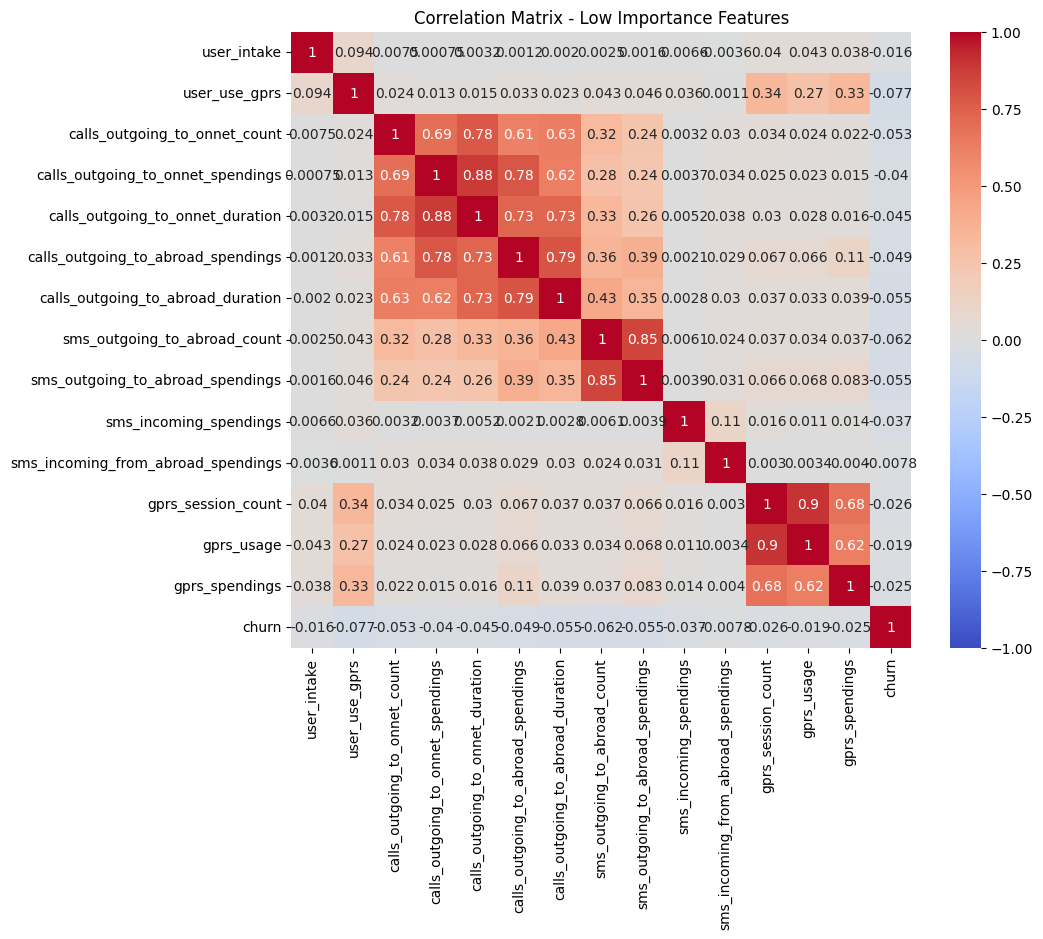

In [ ]:
cols_to_corr = low_importance_cols + ["churn"]
low_imp_corr_with_churn = df[cols_to_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(low_imp_corr_with_churn, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Low Importance Features")
plt.show()

In [ ]:
# Remove
df = df.drop(columns=low_importance_cols)

In [ ]:
# Detect columns leaking data (exactly same as churn except churn column)
leakage_cols = [col for col in df.columns if col != "churn" and df[col].equals(df["churn"])]
print("Data leaking columns (exact same as churn except churn):", leakage_cols)

# Remove if any
if leakage_cols:
    df = df.drop(columns=leakage_cols)
    print(f"Removed columns: {leakage_cols}")
else:
    print("No columns identical to churn other than churn itself, no removal done.")

Data leaking columns (exact same as churn except churn): []
No columns identical to churn other than churn itself, no removal done.


📊 Top 20 Important Features (Based on Random Forest Importance Scores):
                               feature  importance
56                 outgoing_call_ratio    0.074990
47    last_100_calls_outgoing_duration    0.062541
1                        user_lifetime    0.055330
17         calls_outgoing_duration_max    0.053223
58      spending_per_call_out_duration    0.049911
5                       user_spendings    0.049595
57                avg_spending_per_day    0.046897
62  spending_per_last100_call_duration    0.043474
15             calls_outgoing_duration    0.038977
59                 inactive_days_ratio    0.038074
63             reload_inactivity_ratio    0.037308
60               call_duration_per_day    0.034965
18        calls_outgoing_inactive_days    0.033426
13                calls_outgoing_count    0.031733
61                  sms_inactive_ratio    0.028731
3    user_no_outgoing_activity_in_days    0.027308
31          sms_outgoing_inactive_days    0.025164
4         

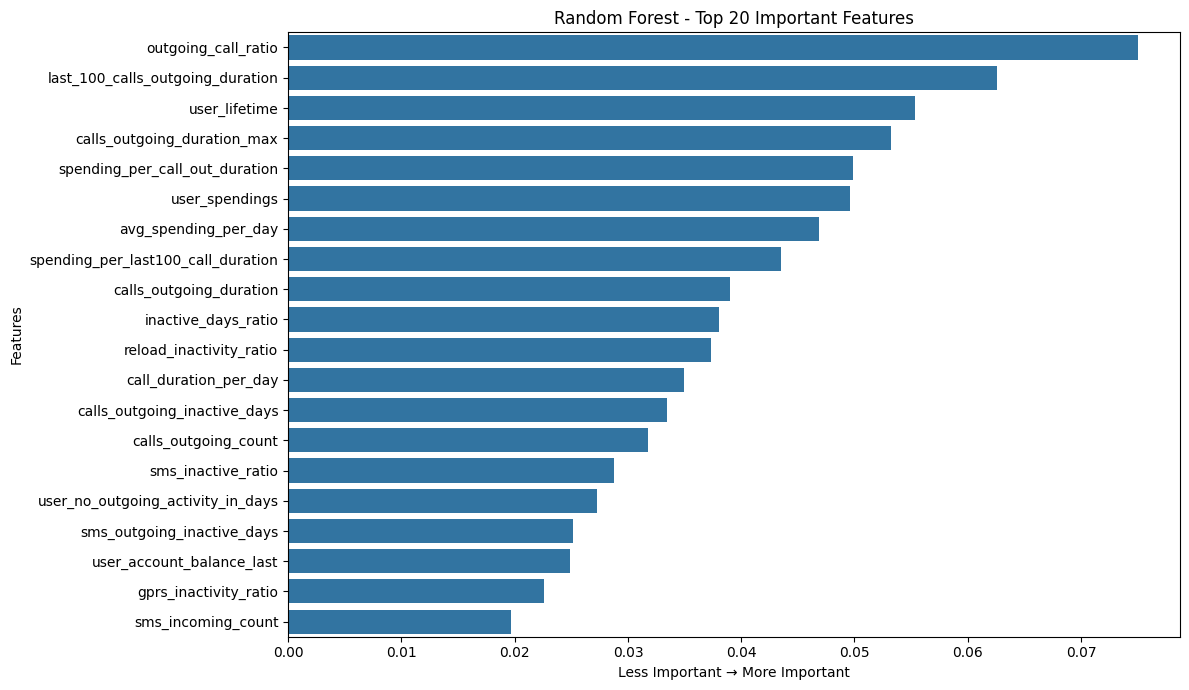

In [ ]:
# Top 20 Important Features Ranking
importance_df = importance_df.sort_values(by="importance", ascending=False)
print("📊 Top 20 Important Features (Based on Random Forest Importance Scores):")
print(importance_df.head(20))

plt.figure(figsize=(12, 7))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))
plt.title("Random Forest - Top 20 Important Features")
plt.xlabel("Less Important → More Important")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("churn_features_final.csv", index=False)

from google.colab import files
files.download("churn_features_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>